In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as ps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import Bbox
from matplotlib.ticker import FuncFormatter
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

def mse(a, b):
    """Mean squared error between two 1D arrays/tensors."""
    if not torch.is_tensor(a):
        a = torch.as_tensor(a)
    if not torch.is_tensor(b):
        b = torch.as_tensor(b)
    a = a.float().flatten()
    b = b.float().flatten()
    return torch.mean((a - b) ** 2)

i_scale = 1e21
noise_strengths = [2, 5, 10, 20]
num_samples = 20                
top_k_num = 5

2.2.3
cuda


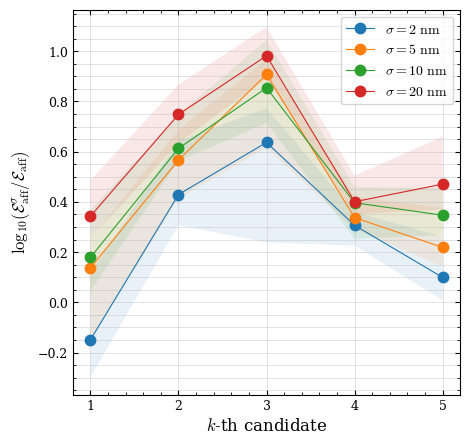

In [5]:
data_path = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/')
cfg_type = "grad_away_1e7"
func = "Cubic"

cal_type = 'recal'

cal_type_dict = {
    "recal": 'Recalibrated',
    "global": "Fixed"
}

n = 50
x = torch.linspace(-1.5, 1.5, n)
if func == 'Parabola':
    y_tgt = x ** 2
elif func == 'ReLU':
    m = nn.ReLU()
    y_tgt = m(x)
elif func == 'Sigmoid':
    m = nn.Sigmoid()
    y_tgt = m(4*x)
elif func == 'Cubic':
    y_tgt = x **3
elif func == 'Sine':
    y_tgt = torch.sin(3*x)

avg_scores = np.zeros((top_k_num, len(noise_strengths)), dtype=np.float64)
std_scores = np.zeros((top_k_num, len(noise_strengths)), dtype=np.float64)  # optional

med_scores = np.zeros((top_k_num, len(noise_strengths)), dtype=np.float64)
q25_scores = np.zeros((top_k_num, len(noise_strengths)), dtype=np.float64)
q75_scores = np.zeros((top_k_num, len(noise_strengths)), dtype=np.float64)

for ns_idx, ns in enumerate(noise_strengths):
    for k in range(top_k_num):
        scores = np.empty(num_samples, dtype=np.float64)
        for s in range(num_samples):
            npz_path = data_path / f'jiggled_topks_{cfg_type}_{func}_sig={ns}/topk={k}_jiggled={s}.npz'
            i_out_np = np.load(npz_path)["current"]

            ref_curve_path = data_path / f'{cfg_type}_{func}_topK/random_mse_func_type={func}_data_type={cfg_type}_topk={k}.npz'
            i_ref_np = np.load(ref_curve_path)["current"]
            if not torch.is_tensor(y_tgt):
                y_tgt = torch.as_tensor(y_tgt)
            i_out = torch.as_tensor(i_out_np, dtype=y_tgt.dtype, device=y_tgt.device) * i_scale
            i_ref = torch.as_tensor(i_ref_np, dtype=y_tgt.dtype, device=y_tgt.device) * i_scale

            G_0, P_0, i_ref_aff = fit_affine_to_target(i_ref, y_tgt)   # global affine from reference
            ref_fitness_score = mse(i_ref_aff, y_tgt)
            if cal_type == 'global':
                i_out_aff = G_0 * i_out + P_0
            elif cal_type == 'recal':
                G_0_recal, P_0_recal, i_out_aff = fit_affine_to_target(i_out, y_tgt)
                i_out_aff = G_0_recal*i_out + P_0_recal
            fitness_score = mse(i_out_aff, y_tgt)
            eps = 1e-12
            score_ratio = fitness_score / max(ref_fitness_score, eps)
            scores[s] = score_ratio.item()

        #avg_scores[k, ns_idx] = scores.mean()
        #std_scores[k, ns_idx] = scores.std(ddof=1)  # optional sample std
        scores = np.log10(scores)
        med = np.median(scores)
        q25, q75 = np.percentile(scores, [25, 75])
        
        med_scores[k, ns_idx] = med
        q25_scores[k, ns_idx] = q25
        q75_scores[k, ns_idx] = q75

k_candidates = np.arange(1, top_k_num + 1, 1)

fig, ax = plt.subplots(figsize=(5, 5))

for i, ns in enumerate(noise_strengths):
    y = med_scores[:, i]
    lo = q25_scores[:, i]
    hi = q75_scores[:, i]
    ax.plot(k_candidates, y, marker='o', markersize=7.5, lw=0.8,
            label=fr'$\sigma = {ns} \, \, \mathrm{{nm}}$')
    ax.fill_between(k_candidates, lo, hi, alpha=0.1)

#ax.axhline(0.0, linestyle='--', lw=0.8, alpha=0.6)  # no-change line

ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both', direction='in')
ax.grid(lw=0.5, alpha=0.5, which='major', axis='x')
ax.grid(lw=0.5, alpha=0.5, which='both', axis='y')

ax.set_xlabel(r'$k$-th candidate')
ax.set_ylabel(r'$\log_{10}\!\left(\mathcal{E}_{\mathrm{aff}}^{\sigma}/\mathcal{E}_{\mathrm{aff}}\right)$')
ax.set_xticks(k_candidates)
ax.legend(loc='best')
"""# save (pick one or both)
np.save(data_path / f"mean_mse_aff_global_{cfg_type}_{func}.npy", avg_scores)
np.save(data_path / f"std_mse_aff_global_{cfg_type}_{func}.npy", std_scores)

# or save both together
np.savez(
    data_path / f"mse_aff_global_stats_{cfg_type}_{func}.npz",
    mean=avg_scores,
    std=std_scores,
    noise_strengths=np.array(noise_strengths),
)"""
plt.show()

uni_1e7
Sigmoid
data_vMB_ring_1e7
Parabola
grad_towards_1e7
Sine
grad_away_1e7
Cubic


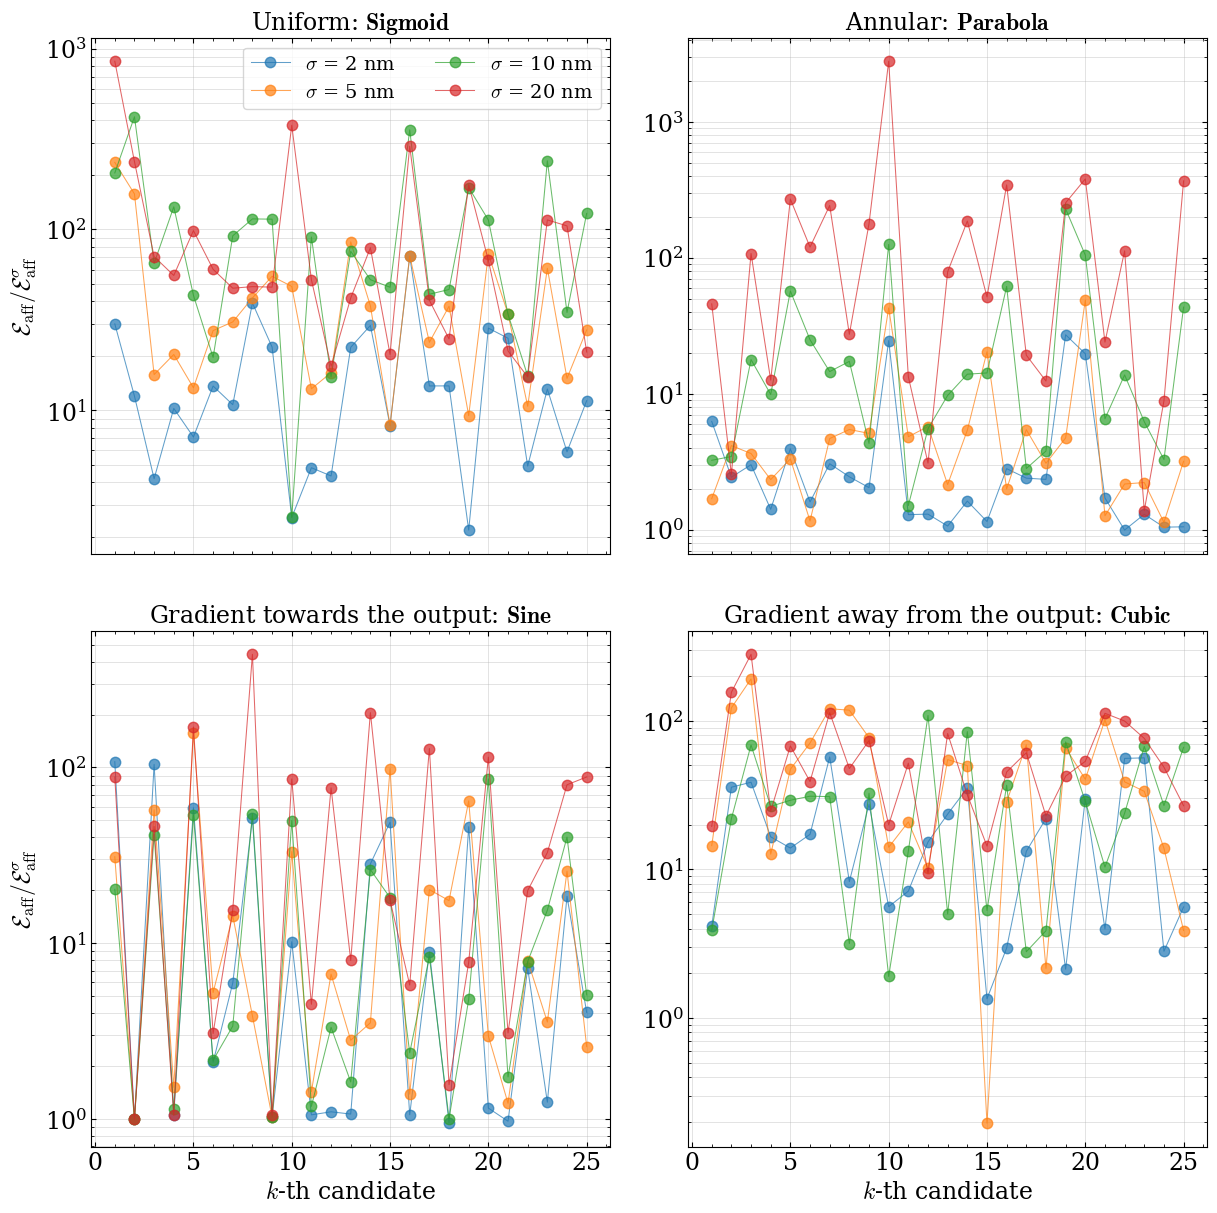

In [13]:
data_dict = {
    "uni_1e7": "Sigmoid",
    "data_vMB_ring_1e7": "Parabola",
    "grad_towards_1e7": "Sine",
    "grad_away_1e7": "Cubic"
}

label_dict = {
    "uni_1e7": r"Uniform: $\mathbf{Sigmoid}$",
    "data_vMB_ring_1e7": "Annular: $\mathbf{Parabola}$",
    "grad_towards_1e7": "Gradient towards the output: $\mathbf{Sine}$",
    "grad_away_1e7": "Gradient away from the output: $\mathbf{Cubic}$"
}

topk_num = 25

#noise_lvl_idx = 0
fig_scale = 3.6
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(4*fig_scale, 4*fig_scale))

label_size = 17
fs = 17
cal_type = 'global'
noise_indices = [1, 2, 3, 5]
for p, (dt, f) in enumerate(data_dict.items()):
    ground_path = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/jiggled_topks_{dt}_{f}/')
    print(dt)
    print(f)
    n = 50
    x = torch.linspace(-1.5, 1.5, n)
    if f == 'Parabola':
        y_tgt = x ** 2
    elif f == 'ReLU':
        m = nn.ReLU()
        y_tgt = m(x)
    elif f == 'Sigmoid':
        m = nn.Sigmoid()
        y_tgt = m(4*x)
    elif f == 'Cubic':
        y_tgt = x **3
    elif f == 'Sine':
        y_tgt = torch.sin(3*x)
    ax = axes[p // 2, p % 2]
    score_differences = []
    score_ratios = []
    for noise_lvl_idx in noise_indices:# range(len(noise_strengths)):
        original_scores_l = []
        post_jiggling_scores_l = []
        for k in range(topk_num): 
            ref_data = np.load(
                f"/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/{dt}_{f}_topK/"\
                f"random_mse_func_type={f}_data_type={dt}_topk={k}.npz"
            )
            i_ref = ref_data['current'] * i_scale
            gain_global, offset_global, i_aff_global = fit_affine_to_target(i_ref, y_tgt)
            gain_global, offset_global = gain_global.numpy(), offset_global.numpy()
            
            file_name = ground_path / f"topk={k}_jiggled={noise_lvl_idx}.npz"
            data = np.load(file_name)     
            i_k_l = data['current'] * i_scale
            a_k_l, b_k_l, i_k_l_aff = fit_affine_to_target(i_k_l, y_tgt)
        
            original_scores_l.append(mse(i_aff_global, y_tgt).item())
            if cal_type == 'global':
                post_jiggling_scores_l.append(mse(gain_global*i_k_l+offset_global, y_tgt).item())
            elif cal_type == 'recal':
                post_jiggling_scores_l.append(mse(i_k_l_aff, y_tgt).item())
        diff_in_score = np.array(original_scores_l) - np.array(post_jiggling_scores_l)
        ratio_score = np.array(post_jiggling_scores_l) / np.maximum(np.array(original_scores_l), 1e-12)
        score_differences.append(diff_in_score)
        score_ratios.append(ratio_score)
    
    """for i, d_s in enumerate(score_differences):
        ax.plot(np.arange(1, len(d_s)+1, 1), d_s, marker='o', markersize=7.5, lw=0.75, alpha=0.7, label=f'$\sigma$ = {noise_strengths[noise_indices[i]]} nm')"""
    for i, r_s in enumerate(score_ratios):
        ax.plot(np.arange(1, len(r_s)+1, 1), r_s, marker='o', markersize=7.5, lw=0.75, alpha=0.7, label=f'$\sigma$ = {noise_strengths[noise_indices[i]]} nm')
    
    ax.set_yscale('log')   
    if (p % 2) == 0:
        #ax.set_ylabel(r'$\vert \mathcal{E}_{\mathrm{aff}} - \mathcal{E}_{\mathrm{aff}}^{\sigma} \vert$', fontsize=fs)
        ax.set_ylabel(r'$\mathcal{E}_{\mathrm{aff}} / \mathcal{E}_{\mathrm{aff}}^{\sigma}$', fontsize=fs)
    ax.minorticks_on()
    ax.tick_params(top=True, right=True, which='both', labelsize=label_size)
    ax.tick_params(direction='in', which='both')
    ax.grid(lw=0.5, alpha=0.5, which='both', axis='y')
    ax.grid(lw=0.5, alpha=0.5, which='major', axis='x')
    ax.tick_params(labelbottom=False, bottom=False)
    if p == 0:
        ax.legend(ncols=2, fontsize=14)
    if (p // 2) == 1:
        ax.tick_params(labelbottom=True, bottom=True)
        ax.tick_params()
        ax.set_xlabel('$k$-th candidate', fontsize=fs)

    ax_title = label_dict[dt]
    ax.set_title(label_dict[dt], fontdict={"fontsize": fs})
#plt.scatter(original_scores, post_jiggling_scores)
fig.subplots_adjust(wspace=0.15, hspace=0.15)
#plt.savefig(f'abs_score_differences_against_sigma_{data_type}_{func_type}_{cal_type}.pdf')
plt.show()